# 1 - Loading The Dataset

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

df = pd.read_csv("../data/raw/patient_diagnosis.csv")
df = df.drop(columns=["Unnamed: 0"])

# 2 - Inspecting Dimensions and data types

In [63]:
print(f"There's {df.shape[0]} rows and {df.shape[1]} columns")
print("\n")
print(df.dtypes)

There's 768 rows and 8 columns


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: object


# 3 - Displaying Sample records

In [64]:
print(df.head(5))
print(df.tail(5))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0      

# 4 - Identifying missing values

In [65]:
print(df.isna().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


# 5 - Identifying duplicates

In [66]:
print(df.duplicated().sum())

0


# 6 - Analysing Descriptive statistics

In [67]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age  
count  768.000000                768.000000  768.000000  
mean    31.992578                  0.471876   33.240885  
std      7.884160                  0.331329   11.760232  
min      0.000000                  0.078000   21.000000  
25%     27.300000        

# 7 - Analyzing Numerical distribution

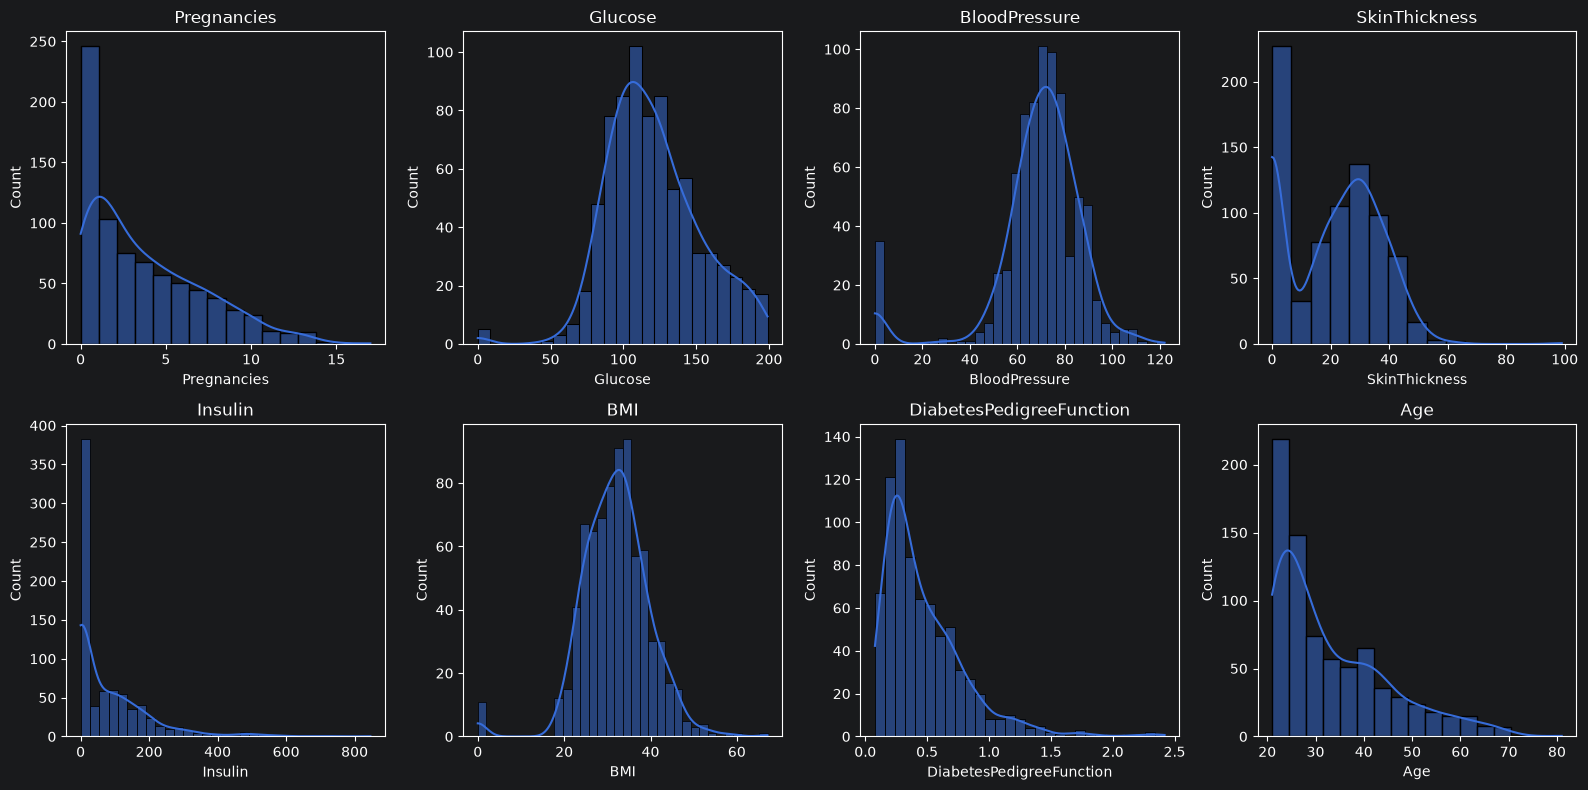

In [68]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, df.columns):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()

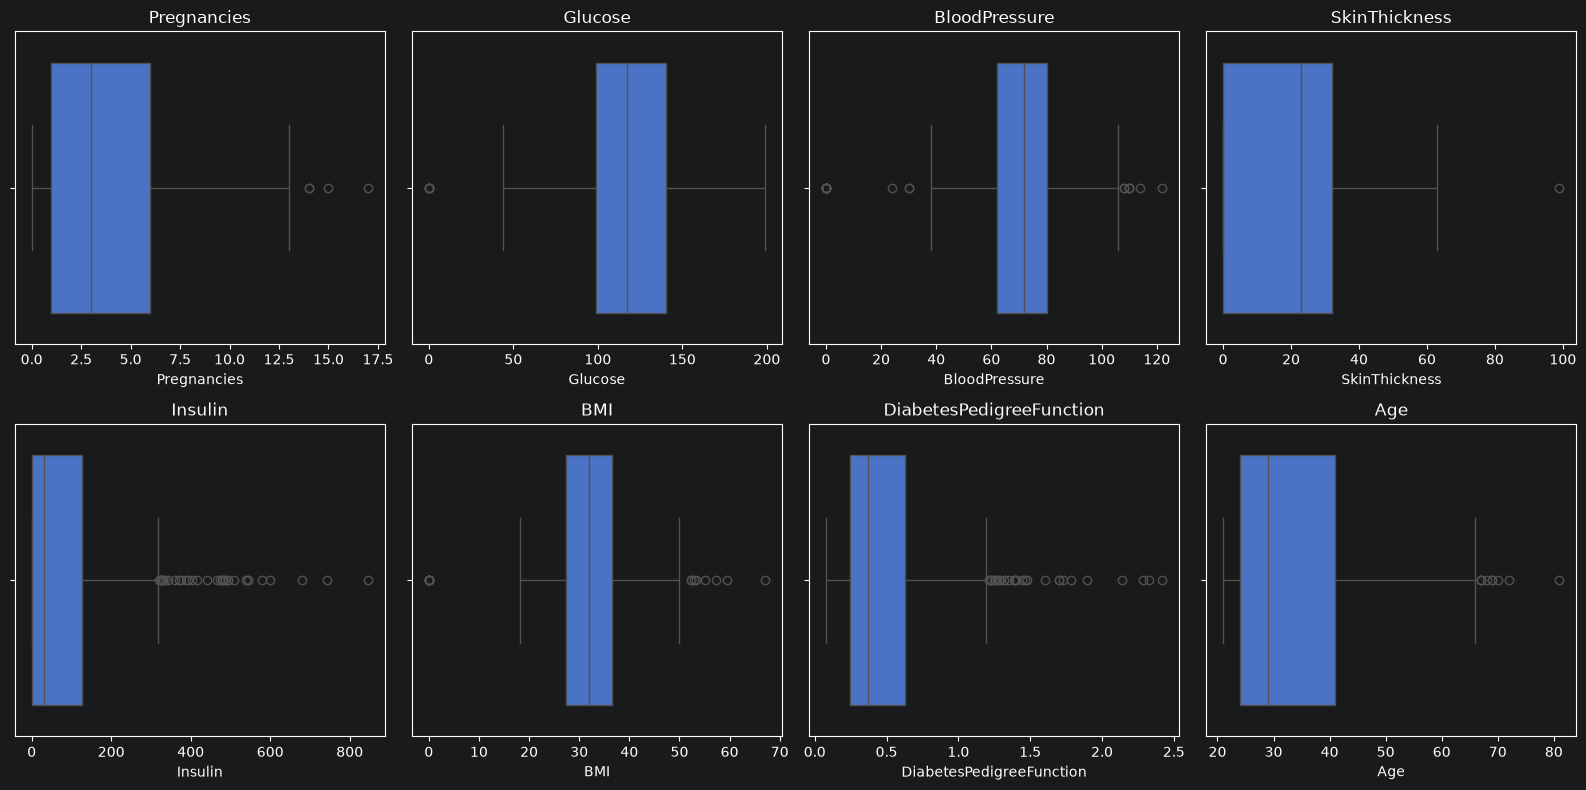

In [69]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, df.columns):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()

# 8 - Detecting outliers and Handling Outliers

In [70]:
df["Glucose"] = np.where(df["Glucose"] == 0,np.nan,df["Glucose"])
df["BloodPressure"] = np.where(df["BloodPressure"] == 0,np.nan,df["BloodPressure"])
df["SkinThickness"] = np.where(df["SkinThickness"] == 0,np.nan,df["SkinThickness"])
df["Insulin"] = np.where(df["Insulin"] == 0,np.nan,df["Insulin"])
df["BMI"] = np.where(df["BMI"] == 0,np.nan,df["BMI"])

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(upper_bound)

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f" {col} : {outliers.shape[0]}")
    print(outliers.sort_values(by=col,ascending=False))
    print("\n")

# winsorizing the outliers exactly : SkinThickness , Insulin , BMI

selected_columns = ["SkinThickness","Insulin","BMI"]

for col in selected_columns :
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper_bound,upper_bound,df[col])

13.5
 Pregnancies : 4
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
159           17    163.0           72.0           41.0    114.0  40.9   
88            15    136.0           70.0           32.0    110.0  37.1   
298           14    100.0           78.0           25.0    184.0  36.6   
455           14    175.0           62.0           30.0      NaN  33.6   

     DiabetesPedigreeFunction  Age  
159                     0.817   47  
88                      0.153   43  
298                     0.412   46  
455                     0.212   38  


204.0
 Glucose : 0
Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
Index: []


104.0
 BloodPressure : 14
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
106            1     96.0          122.0            NaN      NaN  22.4   
691           13    158.0          114.0            NaN      NaN  42.3   
177            0  

# 9 - Checking relationship between Variables

<function matplotlib.pyplot.show(close=None, block=None)>

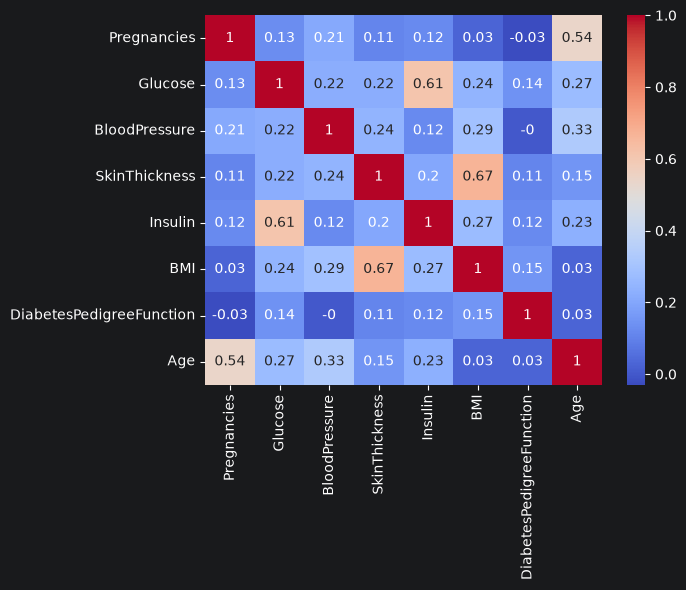

In [71]:
sns.heatmap(
    df.corr().round(2),
    annot=True,
    cmap="coolwarm"
)
plt.show

# 10 - Analyse Feature Variability

In [72]:
for col in df.columns :
    max = df[col].max()
    min = df[col].min()

    print(f"The range from the minimum value and the maximum value of {col} : {max - min}")

The range from the minimum value and the maximum value of Pregnancies : 17
The range from the minimum value and the maximum value of Glucose : 155.0
The range from the minimum value and the maximum value of BloodPressure : 98.0
The range from the minimum value and the maximum value of SkinThickness : 50.0
The range from the minimum value and the maximum value of Insulin : 346.625
The range from the minimum value and the maximum value of BMI : 32.05
The range from the minimum value and the maximum value of DiabetesPedigreeFunction : 2.342
The range from the minimum value and the maximum value of Age : 60


# 11 - Generating Pairplot

<function matplotlib.pyplot.show(close=None, block=None)>

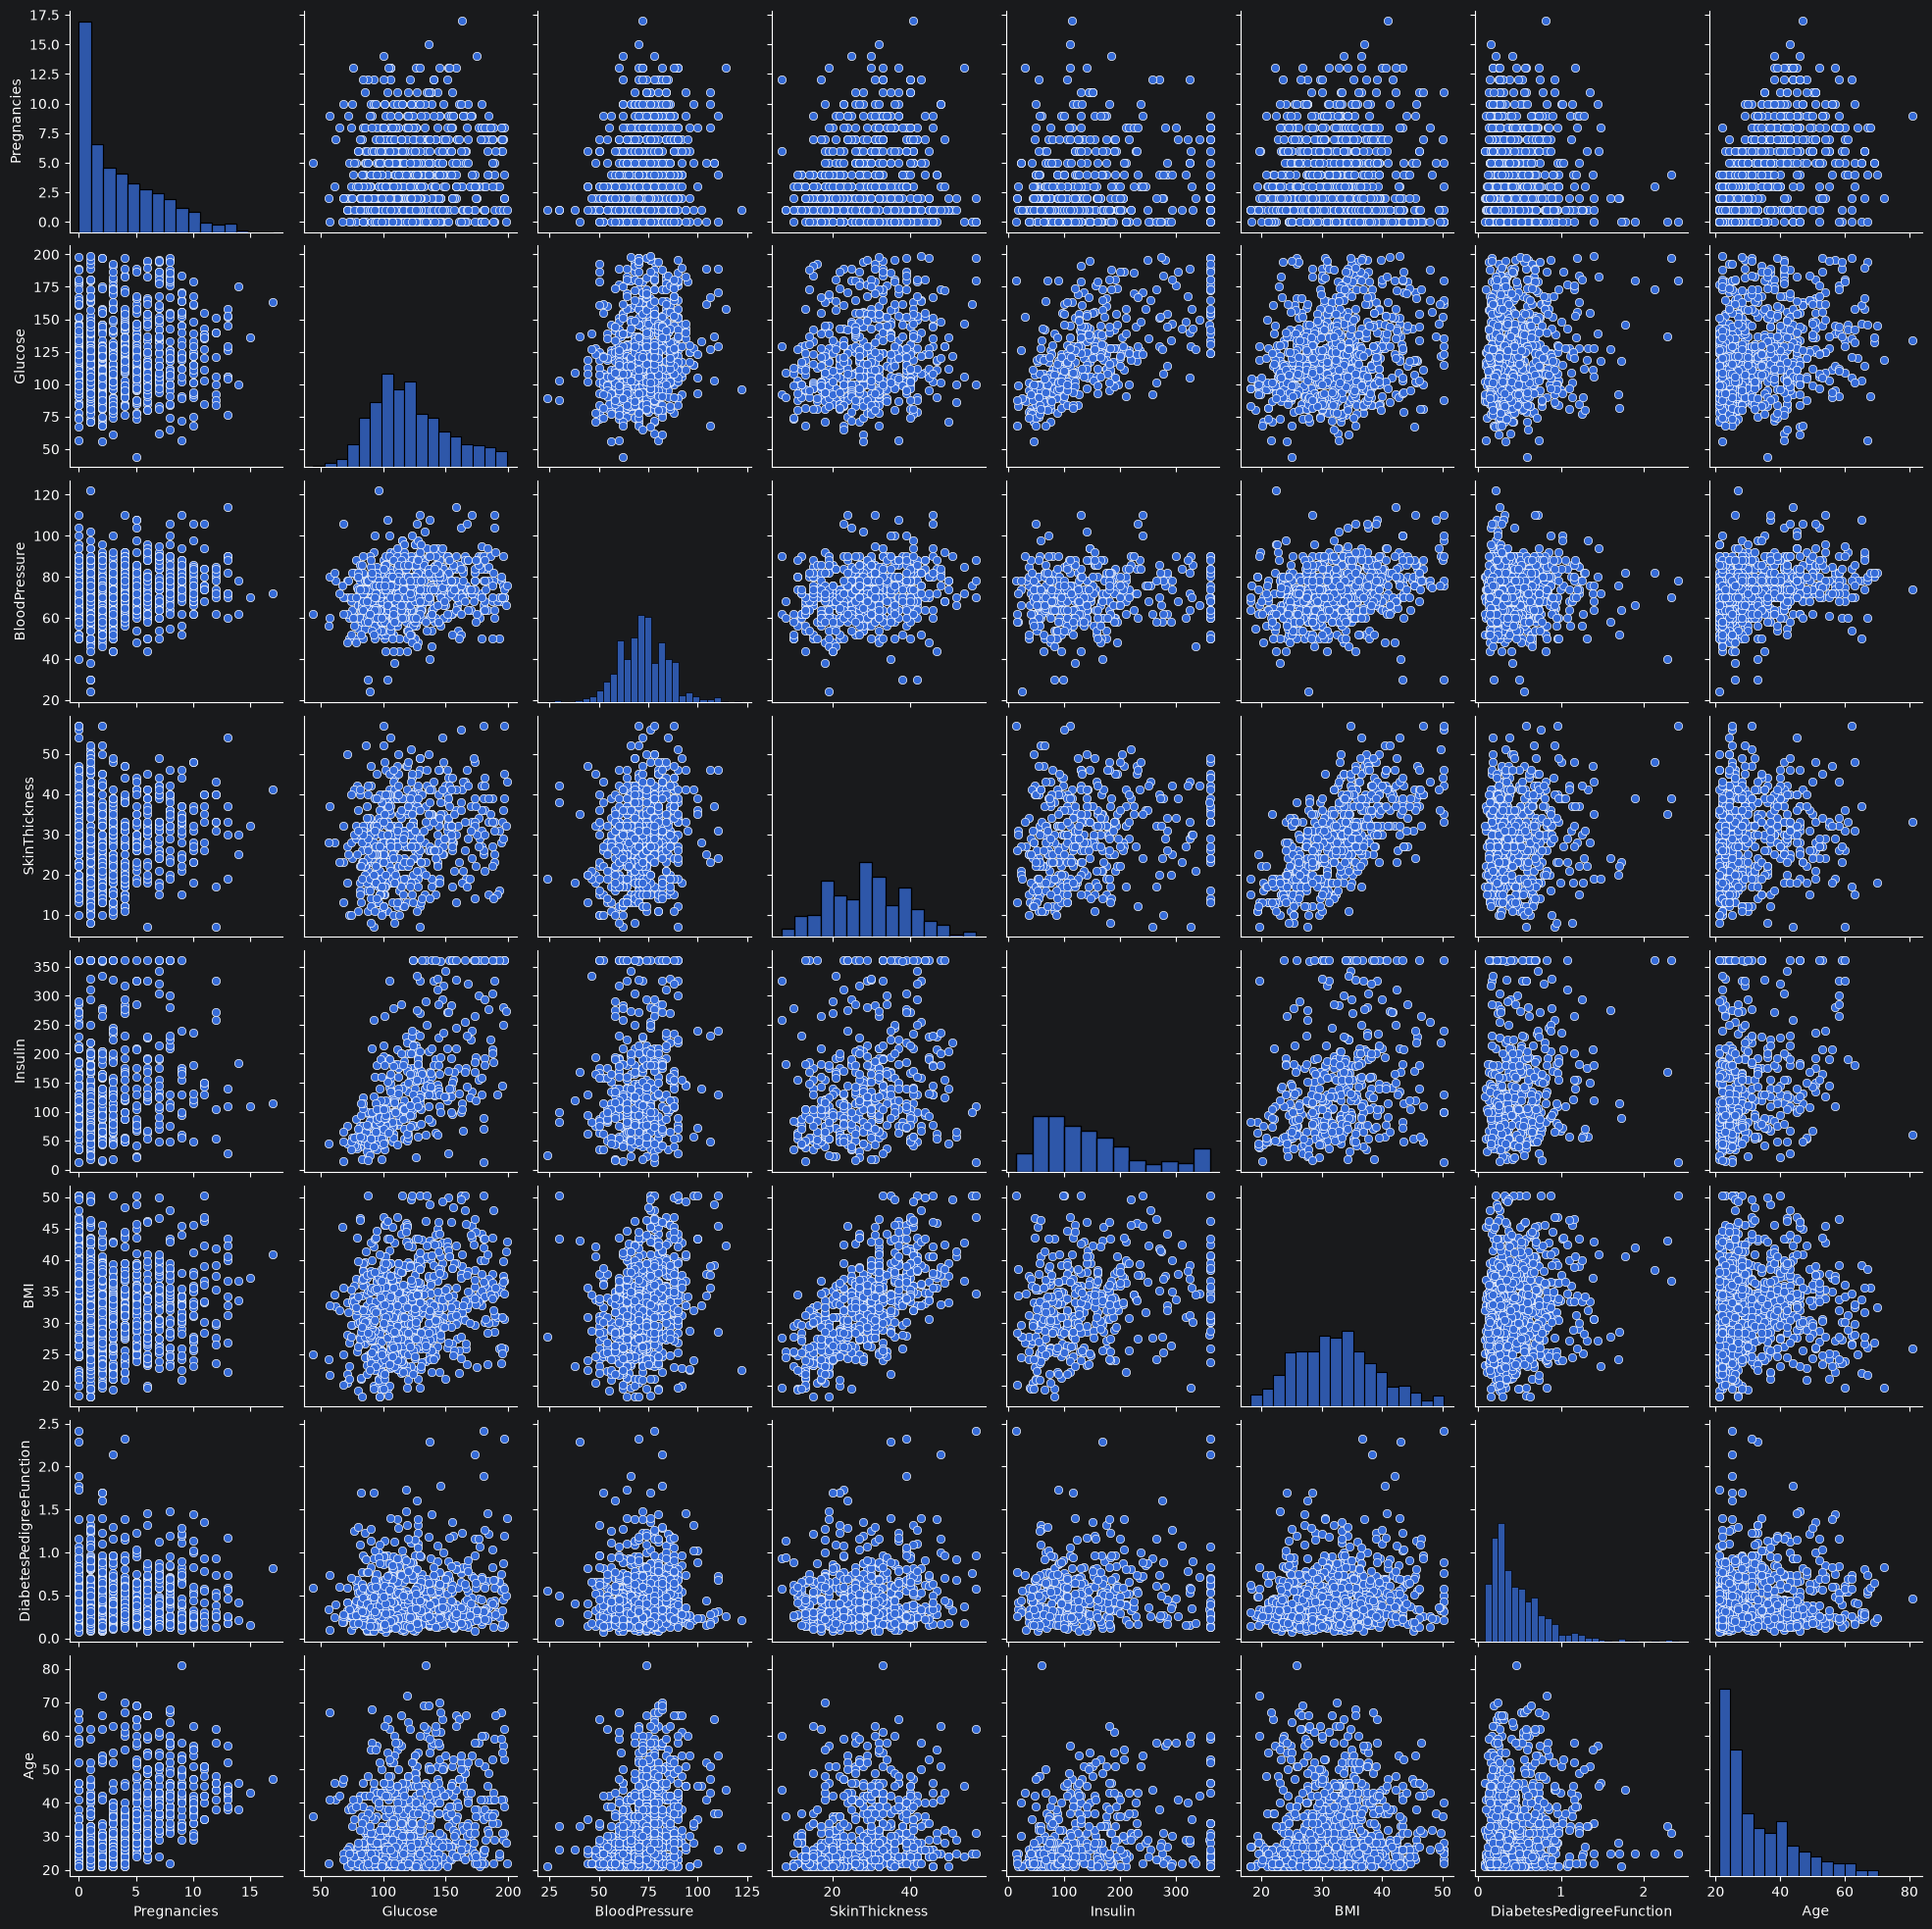

In [73]:
sns.pairplot(df)
plt.show

# 12 - Handeling Missing Values Using KNN Imputer

In [74]:
imputer = KNNImputer(n_neighbors=5)

df[df.columns] = imputer.fit_transform(df)

print(df.head(10))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0          6.0    148.0           72.0           35.0  169.000  33.60   
1          1.0     85.0           66.0           29.0   58.600  26.60   
2          8.0    183.0           64.0           25.8  164.600  23.30   
3          1.0     89.0           66.0           23.0   94.000  28.10   
4          0.0    137.0           40.0           35.0  168.000  43.10   
5          5.0    116.0           74.0           20.6  102.800  25.60   
6          3.0     78.0           50.0           32.0   88.000  31.00   
7         10.0    115.0           77.6           34.4  132.600  35.30   
8          2.0    197.0           70.0           45.0  360.625  30.50   
9          8.0    125.0           96.0           26.4  165.800  32.92   

   DiabetesPedigreeFunction   Age  
0                     0.627  50.0  
1                     0.351  31.0  
2                     0.672  32.0  
3                     0.167  21.0  
4               

# 13 - Correcting Some Columns Types

In [77]:
df["Pregnancies"] = df["Pregnancies"].astype("Int64")
df["Age"] = df["Age"].astype("Int64")

print(df.dtypes)

Pregnancies                   Int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           Int64
dtype: object
